# TP – Unidad 2
El objetivo es medir la incidencia que tiene el uso de instagram en la vida de los usuarios.



## Elementos de Trabajo

### Importar Librerías

In [246]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sbs

### Definir Semilla


In [247]:
seed = 42 # Lo hago solo a fines de buenas prácticas, ya que no haré uso de la función random.
import random
random.seed(seed)
np.random.seed(seed)

### Acceder al Data Set


In [248]:
from google.colab import drive
drive.mount ('/content/drive') # Acccedo a mi Google Drive
df=pd.read_csv ('/content/drive/MyDrive/CURSO BASICO DE HERRAMIENTAS DE DATOS/DATA BASES/ig_df.csv') # Importo Data Set

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Previsualizado

In [249]:
pd.set_option('display.max_columns', None) # Para ver todas las columnas
df.head(10)

,age,gender,country,smoking,alcohol_frequency,perceived_stress_score,daily_active_minutes_instagram,preferred_content_theme
0,64,Female,United Kingdom,No,Rarely,1,74.0,Fashion
1,41,Female,Canada,No,Rarely,4,5.0,Other
2,27,Non-binary,South Korea,Yes,Never,18,233.0,Tech
3,33,Non-binary,Japan,No,Never,23,125.0,Tech
4,51,Female,United Kingdom,No,Several times a week,33,282.0,Travel
5,31,Female,United Kingdom,No,Rarely,12,128.0,Art
6,36,Female,Australia,No,Never,7,5.0,Fashion
7,65,Male,Japan,No,Never,7,5.0,Travel
8,48,Female,United Kingdom,No,Rarely,31,363.0,Fashion
9,52,Female,Japan,No,Weekly,2,5.0,Other


In [250]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541895 entries, 0 to 541894
Data columns (total 8 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             541895 non-null  int64  
 1   gender                          541895 non-null  object 
 2   country                         541895 non-null  object 
 3   smoking                         541895 non-null  object 
 4   alcohol_frequency               541895 non-null  object 
 5   perceived_stress_score          541895 non-null  int64  
 6   daily_active_minutes_instagram  541895 non-null  float64
 7   preferred_content_theme         541895 non-null  object 
dtypes: float64(1), int64(2), object(5)
memory usage: 33.1+ MB


(541895, 8)

## Limpieza

### Filtrado

Tengo un dataset de 541854 filas y 8 columnas. Voy a dejar solamente los países mas representativos de cada continente y voy a eliminar algunas categorías que son irrelevantes para mi análisis.

In [251]:
country_counts = df['country'].value_counts()
display(country_counts)

,count
country,
United Kingdom,123411
Canada,108584
Australia,92522
South Korea,78050
Germany,77329
Japan,61999


In [252]:
df = df.drop(df[df['country'] == 'Germany'].index)
df = df.drop(df[df['country'] == 'Japan'].index)
df = df.drop(columns=['smoking', 'alcohol_frequency'], axis=1)
df.shape

(402567, 6)

### Nulos

In [253]:
df.isna().sum()

,0
age,0
gender,0
country,0
perceived_stress_score,0
daily_active_minutes_instagram,0
preferred_content_theme,0


Observo que carece de nulos.

### Outliers

Me interesa la columna 28 "daily_active_minutes_instagram". Comienzo con un gráfico de caja y bigotes para hacerme una idea de la distribución.

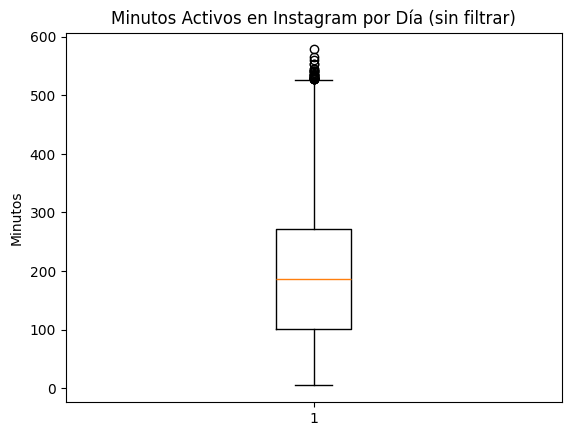

In [254]:
plt.boxplot(df["daily_active_minutes_instagram"])

plt.title("Minutos Activos en Instagram por Día (sin filtrar)")
plt.ylabel("Minutos")

plt.show()

Observo algunos Outliers. Comienzo calculando los límites, fuera de los cuales un valor es considerado un Outlier, como así también los valores de los cuartiles Q1, Q3, mediana, mínimo y máximo.

In [255]:
print("De la columna daily_active_minutes_instagram:")
print("")
min_daily_active_minutes_instagram = df["daily_active_minutes_instagram"].min()
Q1_daily_active = df['daily_active_minutes_instagram'].quantile(0.25)
mediana = df["daily_active_minutes_instagram"].median()
Q3_daily_active = df['daily_active_minutes_instagram'].quantile(0.75)
max_daily_active_minutes_instagram = df["daily_active_minutes_instagram"].max()

print("Minimo:", min_daily_active_minutes_instagram)
print(f"Q1: {Q1_daily_active}")
print("Mediana:", mediana)
print(f"Q3: {Q3_daily_active}")
print("Máximo:", max_daily_active_minutes_instagram)

IQR_daily_active = Q3_daily_active - Q1_daily_active

print(f"IQR: {IQR_daily_active} (Ancho de Caja)")

lower_bound_daily_active = Q1_daily_active - 1.5 * IQR_daily_active
upper_bound_daily_active = Q3_daily_active + 1.5 * IQR_daily_active

if lower_bound_daily_active < 0:
  lower_bound_daily_active = 0
  print (f"Límite inferior para Outliers: {lower_bound_daily_active}")
else:
  print(f"Límite inferior para Outliers: {lower_bound_daily_active}")

if upper_bound_daily_active > max_daily_active_minutes_instagram:
  upper_bound_daily_active = max_daily_active_minutes_instagram
  print (f"Límite inferior para Outliers =: {max_daily_active_minutes_instagram}")
else:
  print(f"Límite superior para Outliers: {upper_bound_daily_active}")

De la columna daily_active_minutes_instagram:

Minimo: 5.0
Q1: 101.0
Mediana: 186.0
Q3: 271.0
Máximo: 578.0
IQR: 170.0 (Ancho de Caja)
Límite inferior para Outliers: 0
Límite superior para Outliers: 526.0


Muestro el mismo gráfico, luego de haber filtrado los valores Outliers y colocando algunas cifras relevantes.

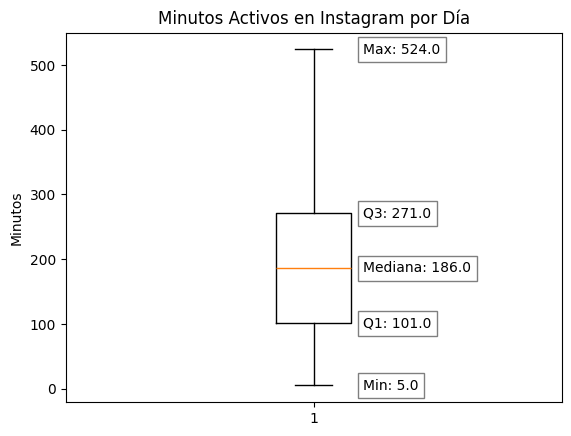

In [256]:
threshold = 526
df = df[df["daily_active_minutes_instagram"] < threshold]

plt.boxplot(df["daily_active_minutes_instagram"])

# Calcular nuevos valores para el dataset fltrado (nótese que pueden variar de los calculados anteriormente, ya que hemos filtrado el dataset)
min_val = df["daily_active_minutes_instagram"].min()
q1_val = df["daily_active_minutes_instagram"].quantile(0.25)
mediana_val = df["daily_active_minutes_instagram"].median()
q3_val = df["daily_active_minutes_instagram"].quantile(0.75)
max_val = df["daily_active_minutes_instagram"].max()

# Agregar texto al plot
plt.text(1.1, min_val, f'Min: {min_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, q1_val, f'Q1: {q1_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, mediana_val, f'Mediana: {mediana_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, q3_val, f'Q3: {q3_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, max_val, f'Max: {max_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))

plt.title("Minutos Activos en Instagram por Día")
plt.ylabel("Minutos")

plt.show()

## Análisis

Podemos mostrar algunas propiedades más que nos otorga este set de datos, como la distribución de usuarios según país y el nivel de minutos activos promedio de cada país.

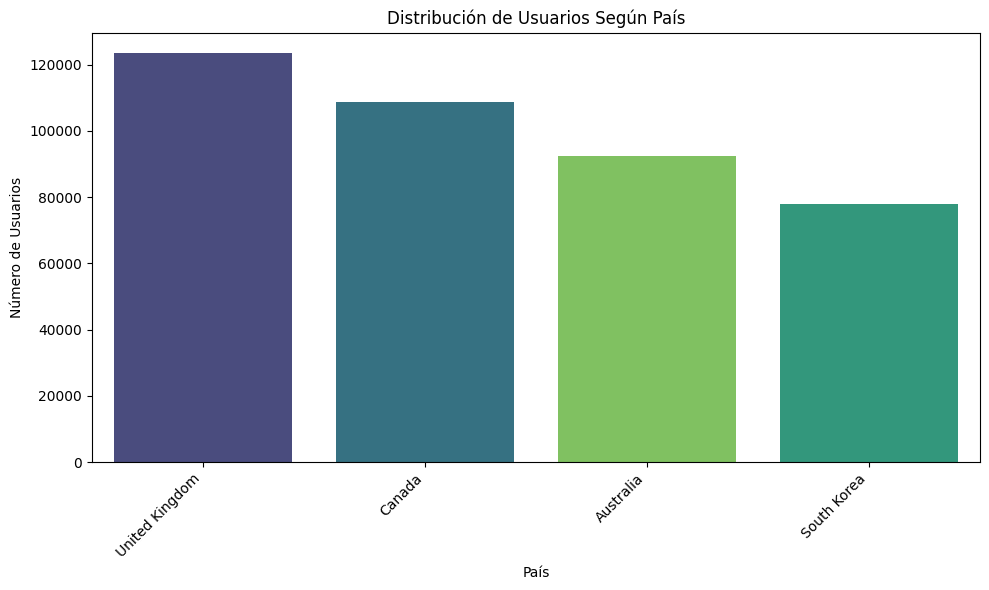

In [257]:
plt.figure(figsize=(10, 6))
sbs.countplot(data=df, x='country', order=df['country'].value_counts().index, hue='country', palette='viridis', legend=False)
plt.title('Distribución de Usuarios Según País')
plt.xlabel('País')
plt.ylabel('Número de Usuarios')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Voy a buscar correlaciones relevantes con la columna "daily_active_minutes_instagram", para eso buscaré columnas que estén correlacionadas con esta en un factor mayor a 0,8.

In [258]:
correlation_matrix = df.corr(numeric_only=True)

daily_active_correlations = []

correlations_with_daily_active = correlation_matrix['daily_active_minutes_instagram']

for column, correlation_value in correlations_with_daily_active.items():

    if column != 'daily_active_minutes_instagram' and abs(correlation_value) > 0.8:
        daily_active_correlations.append({
            'Column': column,
            'Correlation': correlation_value
        })

if daily_active_correlations:
    print("Columnas con alta correlación (> 0.8) con 'daily_active_minutes_instagram':")
    for pair in daily_active_correlations:
        print(f"   {pair['Column']}: {pair['Correlation']:.2f}")
else:
    print("No se encontraro colummnas altamente correlacionadas (abs > 0.8) con 'daily_active_minutes_instagram'.")

Columnas con alta correlación (> 0.8) con 'daily_active_minutes_instagram':
   perceived_stress_score: 0.84


Construyo scatter plot con línea de regresión utilizando herramientas de optimizado de visualización.

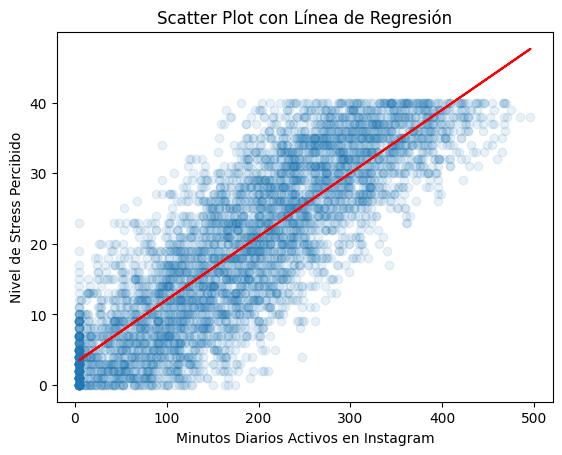

Slope (m): 0.09


In [259]:
df_sample = df.sample(5000) # Utilizo una muestra menor para evitar densidad

x = df_sample["daily_active_minutes_instagram"]
y = df_sample["perceived_stress_score"]

plt.scatter(x, y, alpha=0.1) # Ploteo reduciendo la opacidad de los puntos para mejor visualización

m, b = np.polyfit(x, y, 1) # Cálculo de línea de regresión

plt.plot(x, m*x + b, color='red') # Ploteo  de línea de regresion en otro color

plt.xlabel("Minutos Diarios Activos en Instagram")
plt.ylabel("Nivel de Stress Percibido")
plt.title("Scatter Plot con Línea de Regresión")

plt.show()
print(f"Slope (m): {m:.2f}")


El gráfico muestra la clara correlación entre los minutos en los que los usuarios están activos en Instagram y el nivel de stress percibido en ellos.

Podemos hacer el mismo análisis pero separando por rango etario, para ver si hay algún rango con comportamiento diferenciado.

Comienzo calculando los cuartiles de edad.

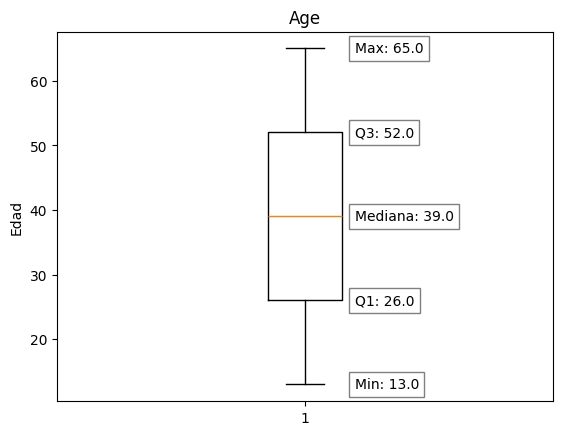

In [260]:
plt.boxplot(df["age"])

# Calcular valores de cuartiles de edad
min_val = df["age"].min()
q1_val = df["age"].quantile(0.25)
mediana_val = df["age"].median()
q3_val = df["age"].quantile(0.75)
max_val = df["age"].max()

# Agregar texto al plot
plt.text(1.1, min_val, f'Min: {min_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, q1_val, f'Q1: {q1_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, mediana_val, f'Mediana: {mediana_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, q3_val, f'Q3: {q3_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))
plt.text(1.1, max_val, f'Max: {max_val:.1f}', va='center', ha='left', bbox=dict(facecolor='white', alpha=0.5))

plt.title("age")

plt.title("Age")
plt.ylabel("Edad")

plt.show()

Construyo scatter plots separados para cada rango etario.

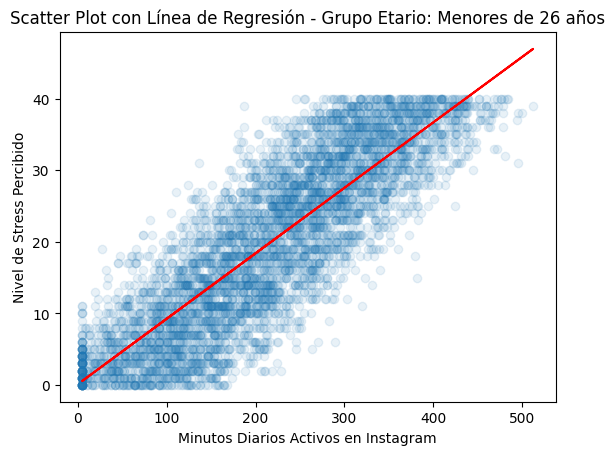

Slope (m): 0.09


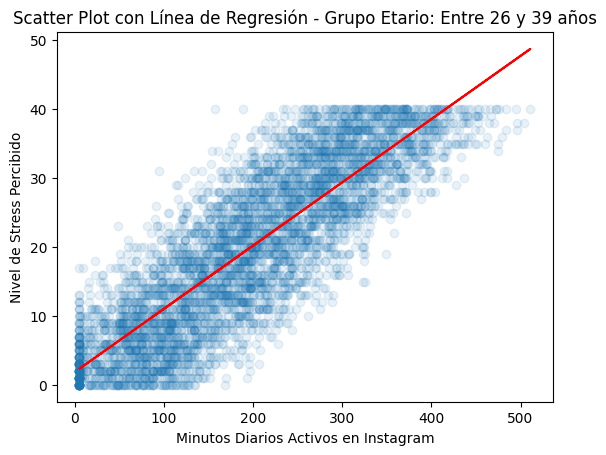

Slope (m): 0.09


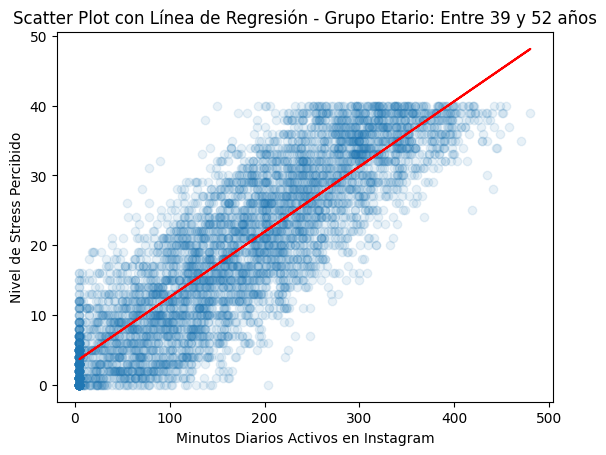

Slope (m): 0.09


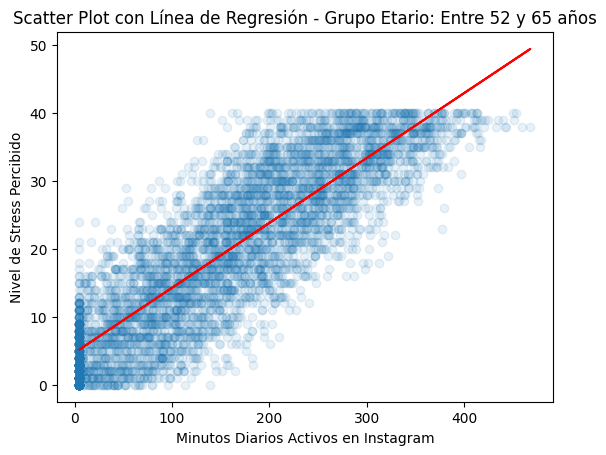

Slope (m): 0.10


In [261]:
dfq1 = df[df["age"] < 26]
dfq2 = df[(df["age"] >= 26) & (df["age"] < 39)]
dfq3 = df[(df["age"] >= 39) & (df["age"] < 52)]
dfq4 = df[df["age"] >= 52]


dfq1_sample = dfq1.sample(5000) # Utilizo una muestra menor para evitar densidad
x = dfq1_sample["daily_active_minutes_instagram"]
y = dfq1_sample["perceived_stress_score"]
plt.scatter(x, y, alpha=0.1) # Ploteo reduciendo la opacidad de los puntos para mejor visualización
m, b = np.polyfit(x, y, 1) # Cálculo de línea de regresión
plt.plot(x, m*x + b, color='red') # Ploteo  de línea de regresion en otro color
plt.xlabel("Minutos Diarios Activos en Instagram")
plt.ylabel("Nivel de Stress Percibido")
plt.title("Scatter Plot con Línea de Regresión - Grupo Etario: Menores de 26 años")
plt.show()
print(f"Slope (m): {m:.2f}")


dfq2_sample = dfq2.sample(5000) # Utilizo una muestra menor para evitar densidad
x = dfq2_sample["daily_active_minutes_instagram"]
y = dfq2_sample["perceived_stress_score"]
plt.scatter(x, y, alpha=0.1) # Ploteo reduciendo la opacidad de los puntos para mejor visualización
m, b = np.polyfit(x, y, 1) # Cálculo de línea de regresión
plt.plot(x, m*x + b, color='red') # Ploteo  de línea de regresion en otro color
plt.xlabel("Minutos Diarios Activos en Instagram")
plt.ylabel("Nivel de Stress Percibido")
plt.title("Scatter Plot con Línea de Regresión - Grupo Etario: Entre 26 y 39 años")
plt.show()
print(f"Slope (m): {m:.2f}")


dfq3_sample = dfq3.sample(5000) # Utilizo una muestra menor para evitar densidad
x = dfq3_sample["daily_active_minutes_instagram"]
y = dfq3_sample["perceived_stress_score"]
plt.scatter(x, y, alpha=0.1) # Ploteo reduciendo la opacidad de los puntos para mejor visualización
m, b = np.polyfit(x, y, 1) # Cálculo de línea de regresión
plt.plot(x, m*x + b, color='red') # Ploteo  de línea de regresion en otro color
plt.xlabel("Minutos Diarios Activos en Instagram")
plt.ylabel("Nivel de Stress Percibido")
plt.title("Scatter Plot con Línea de Regresión - Grupo Etario: Entre 39 y 52 años")
plt.show()
print(f"Slope (m): {m:.2f}")


dfq4_sample = dfq4.sample(5000) # Utilizo una muestra menor para evitar densidad
x = dfq4_sample["daily_active_minutes_instagram"]
y = dfq4_sample["perceived_stress_score"]
plt.scatter(x, y, alpha=0.1) # Ploteo reduciendo la opacidad de los puntos para mejor visualización
m, b = np.polyfit(x, y, 1) # Cálculo de línea de regresión
plt.plot(x, m*x + b, color='red') # Ploteo  de línea de regresion en otro color
plt.xlabel("Minutos Diarios Activos en Instagram")
plt.ylabel("Nivel de Stress Percibido")
plt.title("Scatter Plot con Línea de Regresión - Grupo Etario: Entre 52 y 65 años")
plt.show()
print(f"Slope (m): {m:.2f}")

Vemos que en todos los cuartiles de edad se verifica la misma norma: a mayor nivel consumo de Instagram, mayor nivel de stress percibido.

También podemos hacernos de la media de consumo de la red social en los países analizados, para ver si alguno prevalece sobre otros.

In [262]:
country_instagram_usage = df.groupby('country')['daily_active_minutes_instagram'].mean().sort_values(ascending=False)
display(country_instagram_usage)

,daily_active_minutes_instagram
country,
Australia,188.759928
United Kingdom,188.376697
South Korea,187.925298
Canada,187.919469


De aquí que los hábios de consumo de la red social Instagram son muy similares en todos los países estudiados.

Adicionalmente, analizamos, con un gráfico de torta los diferentes tópicos de preferencia de los usuarios.

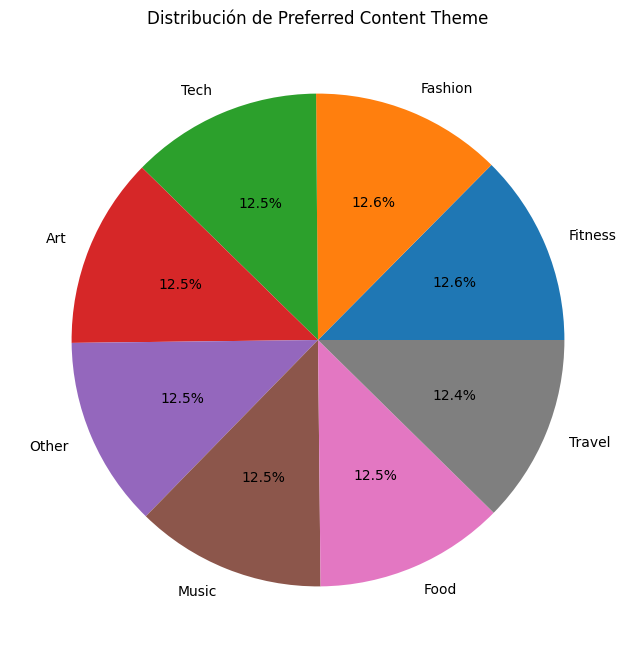

In [267]:
import matplotlib.pyplot as plt

# Contar valores por categoría
counts = df['preferred_content_theme'].value_counts()

# Crear gráfico de torta
plt.figure(figsize=(8, 8))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%')

plt.title('Distribución de Preferred Content Theme')
plt.show()

De aquí que ningún tópico tiene una clara prevalencia sobre los otros.


## Conclusiones

Del Data Set al que pudimos acceder, hemos podido sacar conclusiones de los paises de mayor uso de la red social Instagram por cada continente (con la exepción de África). Estos son: Reino Unido, Canadá, Australia y Korea del Sur.

En cada uno de estos paises, los usuarios de Instagram tienen un uso promedio de casi 190 minutos diarios.

Globalmente, se registran usuarios registrados con edades desde los 13 a los 65 años, con una mediana de 39 años.

Globalmente, la distribución de los tópicos de consumo (preferred_content_theme) es equitativa. No se muestra un tópico que prevalezca notoriamente.

De mayor a menor, los paises con más cantidad de usuarios de Instagram son: Reino Unido, Canadá, Australia y, por últmo, Korea del Sur.

Se observa una correlación entre la cantidad de minutos de uso diario de la red social Instagram y el nivel de stress percibido en los usuarios.
Dicha correlación es observable de igual manera en cada uno de los 4 rangos etarios (separados por cuartiles).